In [1]:
import torch

def create_mask(tensor, p):
    # Ensure p is between 0 and 100
    p = max(0, min(p, 100))
    
    # Calculate the number of elements to select based on percentage p
    num_elements_to_select = int((tensor.size(2) * tensor.size(3) * p) / 100)
    
    # Initialize the mask with zeros
    mask = torch.zeros_like(tensor, dtype=torch.float)
    
    for a in range(tensor.size(0)):
        for b in range(tensor.size(1)):
            # Flatten the (c, d) dimensions
            slice_flat = tensor[a, b].flatten()
            
            # Sort elements in descending order and get the indices
            _, indices = torch.sort(slice_flat, descending=True)
            
            # Select indices corresponding to the top p%
            selected_indices = indices[:num_elements_to_select]
            
            # Create a mask for the selected elements
            slice_mask = torch.zeros_like(slice_flat, dtype=torch.float)
            slice_mask[selected_indices] = 1
            
            # Reshape the mask back to the (c, d) dimensions and assign to the mask tensor
            mask[a, b] = slice_mask.reshape(tensor.size(2), tensor.size(3))
    
    return mask

# Example usage
tensor = torch.randint(0, 10, (1, 1, 4, 4))  # Example 4D tensor with integers
p = 50  # Example percentage

mask = create_mask(tensor, p)
print("Original Tensor:\n", tensor)
print("Mask Tensor:\n", mask)


Original Tensor:
 tensor([[[[2, 2, 4, 9],
          [7, 6, 2, 5],
          [6, 4, 7, 1],
          [9, 5, 4, 6]]]])
Mask Tensor:
 tensor([[[[0., 0., 0., 1.],
          [1., 1., 0., 1.],
          [1., 0., 1., 0.],
          [1., 0., 0., 1.]]]])


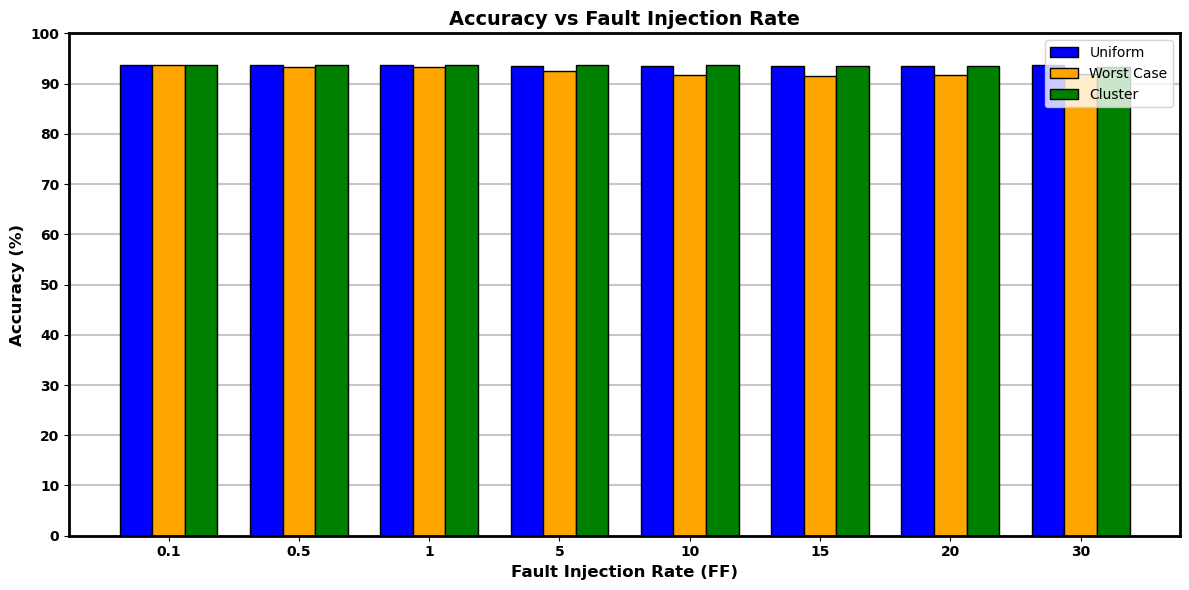

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Data extracted from your input
categories = ['0.1', '0.5', '1', '5', '10', '15', '20', '30']
uniform = [93.78, 93.74, 93.67, 93.49, 93.43, 93.47, 93.50, 93.60]
worst_case = [93.79, 93.35, 93.29, 92.50, 91.69, 91.48, 91.77, 91.89]
cluster = [93.75, 93.74, 93.76, 93.69, 93.65, 93.57, 93.53, 93.23]

bar_width = 0.25  # Width of the bars
index = np.arange(len(categories))  # The x locations for the groups

# Create the figure and the axes
fig, ax = plt.subplots(figsize=(12, 6))

# Plotting the data
bar1 = ax.bar(index, uniform, bar_width, label='Uniform', color='blue', edgecolor='black')
bar2 = ax.bar(index + bar_width, worst_case, bar_width, label='Worst Case', color='orange', edgecolor='black')
bar3 = ax.bar(index + 2 * bar_width, cluster, bar_width, label='Cluster', color='green', edgecolor='black')

# Customize the plot
ax.set_xlabel('Fault Injection Rate (FF)', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_xticks(index + bar_width)
ax.set_xticklabels(categories, fontsize=10, fontweight='bold')
ax.set_yticks(np.arange(0, 101, 10))
ax.set_yticklabels(np.arange(0, 101, 10), fontsize=10, fontweight='bold')
ax.set_title('Accuracy vs Fault Injection Rate', fontsize=14, fontweight='bold')
ax.grid(which='major', axis='y', linestyle='-', linewidth=0.75, alpha=0.7)
ax.set_axisbelow(True)

# Bolden the axes and grid lines
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

for line in ax.yaxis.get_gridlines():
    line.set_linestyle('-')
    line.set_linewidth(1.5)

# Adding a legend
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()
